# Perceptron - Pima Indians Diabetes

Conjutno de datos disponible en sklearn.datasets.getch_openml. Este conjunto de datos contiene informacion de clinica de paicnetes, como nivel de glucosa, presion arterial, indice de masa corporal, entre otros, y la eitqueta indica si la persona tiene diabetes o no.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pylab as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_openml

In [2]:
# Cargar el dataset desde OpenMl
diabetes = fetch_openml(name = 'diabetes', version = 1, as_frame = True)
df = diabetes.frame
df

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,tested_negative
764,2,122,70,27,0,36.8,0.340,27,tested_negative
765,5,121,72,23,112,26.2,0.245,30,tested_negative
766,1,126,60,0,0,30.1,0.349,47,tested_positive


In [3]:
# Inspeccion de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   preg    768 non-null    int64   
 1   plas    768 non-null    int64   
 2   pres    768 non-null    int64   
 3   skin    768 non-null    int64   
 4   insu    768 non-null    int64   
 5   mass    768 non-null    float64 
 6   pedi    768 non-null    float64 
 7   age     768 non-null    int64   
 8   class   768 non-null    category
dtypes: category(1), float64(2), int64(6)
memory usage: 49.0 KB


In [4]:
# Separara caracterisitcas (X) y eitqueta (Y)
# Obtener X eliminando la columan de etiqueta
X = df.drop(columns=['class'])
# Obtener Y conviritendo la eitqueta en un valor numerico
y = df['class'].apply(lambda x: 1 if x == 'tested_positive' else 0)

In [5]:
# Dividir el dataset en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 13, 
    stratify = y
)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_train

array([[-8.41605003e-01, -9.89798151e-01,  4.63948283e-01, ...,
        -4.24044584e-02, -3.34643567e-01, -3.58032553e-01],
       [ 3.49052766e-01,  7.10811544e-01,  4.63948283e-01, ...,
         1.66791584e+00, -8.65953338e-01,  1.20167410e+00],
       [ 2.73036830e+00,  1.85168548e-01,  1.09780160e+00, ...,
         1.45741488e+00,  3.27216603e-01,  7.68422251e-01],
       ...,
       [-8.41605003e-01, -3.71077366e+00,  2.52663843e-01, ...,
        -6.08125788e-01, -5.35023252e-01, -1.05123551e+00],
       [-1.13926944e+00, -4.02314802e-01, -3.81189476e-01, ...,
         5.62785801e-01,  8.55490318e-01, -7.04634031e-01],
       [ 5.13883239e-02,  1.54248371e-01,  5.69590503e-01, ...,
        -2.93552845e-03,  1.84521979e-01, -5.31333292e-01]],
      shape=(614, 8))

In [7]:
perceptron = Perceptron(max_iter = 4000, eta0 = 0.01, random_state = 13)
perceptron.fit(X_train, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",4000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.01
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",13


In [8]:
y_pred = perceptron.predict(X_test)

In [9]:
eficiencia = accuracy_score(y_test, y_pred)
print(f'Precisión del perceptron {eficiencia:.2f}')
print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred))

Precisión del perceptron 0.73

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



In [10]:
# Obtener pesos
pesos = perceptron.coef_
# Obtener Sesgo
sesgos = perceptron.intercept_

In [11]:
print(f'Matriz se pesos: {pesos}')
print(f'\nVector de segos: {sesgos}')


Matriz se pesos: [[ 0.01436934  0.05782425 -0.00675233 -0.02544361  0.03097658 -0.00562786
   0.02933507  0.00791284]]

Vector de segos: [-0.01]


In [12]:
X_subset = X_train[:,[1,5]]
y_subset = y_train

In [13]:
perceptron.fit(X_subset, y_subset)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",4000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.01
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",13


In [14]:
w = perceptron.coef_
b = perceptron.intercept_

In [15]:
x1_min, x1_max = X_subset[:,0].min(), X_subset[:, 0].max()
x2_min, x2_max = X_subset[:,1].min(), X_subset[:,1].max()
x1_values = np.linspace(x1_min, x1_max, 100)
x2_values = (-w[0][0]/w[0][1]*x1_values - (b[0]/w[0][1]))

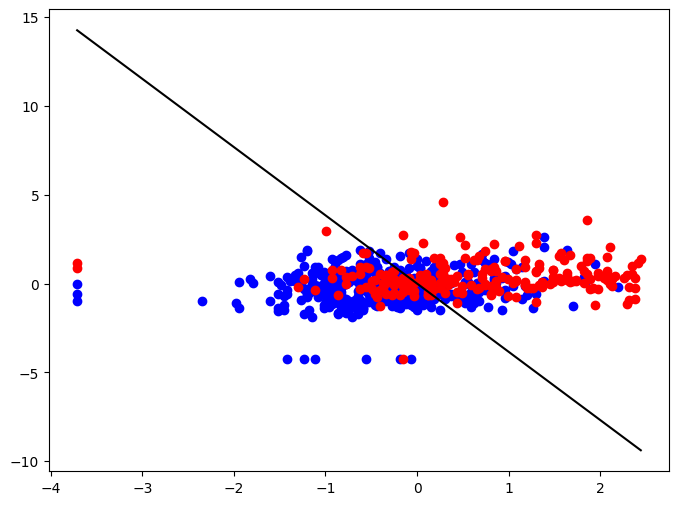

In [16]:
plt.figure(figsize = (8,6))
plt.scatter(X_subset[y_subset==0][:, 0], X_subset[y_subset==0][:, 1], color = 'blue', label='No diabetico')
plt.scatter(X_subset[y_subset==1][:, 0], X_subset[y_subset==1][:, 1], color = 'red', label='Diabetico')
plt.plot(x1_values, x2_values, 'k-', label='Frontera de decision')

# Aplicar MLP

In [17]:
from sklearn.neural_network import MLPClassifier
# Crear un perceptron multicapa con 1 capa oculta de 5 neuronas
mlp = MLPClassifier(hidden_layer_sizes=(5,), activation = 'logistic', max_iter = 1500, random_state =  15)

# Entrenar
mlp.fit(X_train, y_train)

# Verificar cantidad de capas
print(f'Numero de capas en la red: {len(mlp.coefs_)}. (Incluye capas ocultas y capa de salida')
print(f'Neuronas en la capa oculta: {mlp.hidden_layer_sizes[0]}')

Numero de capas en la red: 2. (Incluye capas ocultas y capa de salida
Neuronas en la capa oculta: 5


In [18]:
# Obtern pesos y bias
w = mlp.coefs_
b = mlp.intercepts_
print(f'Pesos:\n{w}')
print(f'Interceptos:\n{b}')

Pesos:
[array([[-0.07281873, -0.30446289, -0.52967134, -0.21817829, -0.30871235],
       [-1.43457531, -1.2143614 , -1.1809004 , -1.05040244, -1.48335172],
       [ 0.29174678,  0.1182971 ,  0.28526169,  0.27708441,  0.316173  ],
       [ 0.12380817,  0.16437318, -0.01970732, -0.09717486,  0.18574943],
       [ 0.05998348, -0.10100022,  0.15487469, -0.05912338,  0.00473577],
       [-0.74721042, -1.0664889 , -0.69506302, -0.76071877, -0.83045235],
       [-0.78581567, -0.52676275, -0.36663753, -0.39014477, -0.51460821],
       [-0.3613025 , -0.32864076, -0.54273859, -0.10437433, -0.48379128]]), array([[-0.66030242],
       [-1.02801948],
       [-1.12265332],
       [-0.17426949],
       [-0.72952803]])]
Interceptos:
[array([-0.20303229, -0.29310785, -0.39278388, -0.19365182, -0.28839695]), array([0.80872312])]


In [19]:
# Realizar predicciones
y_pred2 = mlp.predict(X_test)

In [20]:
y_pred2

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0])

In [27]:
eficiencia2 = accuracy_score(y_test, y_pred2)
print(f'Eficiencia del MLP: {eficiencia:.2f}')
print('\nReporte de clasificacion')
print(classification_report(y_test, y_pred2))

Eficiencia del MLP: 0.73

Reporte de clasificacion
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.63      0.67        54

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.76       154
weighted avg       0.78      0.79      0.78       154



# Aplicación de CNN

In [32]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, MaxPool1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [33]:
# Reroganiza el conjunto a #D
X_train = X_train.reshape(614, 8, 1)
X_test = X_test.reshape(154, 8, 1)

In [35]:
# Preparacion del moedel
model = Sequential()

In [39]:
model.add(Conv1D(filters=16, kernel_size=2, activation='relu', input_shape = (8,1)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Conv1D(8,2, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(8, 'relu'))
model.add(Dropout(0.2))

model.add(Dense(1, 'sigmoid'))

In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 7, 16)               │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 16)               │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 6, 8)                │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 6, 8)                │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 8)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 5, 16)               │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 5, 16)               │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 5, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 4, 8)                │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 4, 8)                │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4, 8)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
model.compile(
    optimizer = 
)